# Operating US Nuclear Reactors by Region

This notebook builds a list of all operating US nuclear power reactors from the [Nuclear Regulatory Commission (NRC)](https://www.nrc.gov/facilities-safety/facility-finder/reactors) website and groups them by NRC region.

We first need to download the webpage i.e. we need to fetch the HTML and write that onto a file on the disk. We need the following libraries for this purpose.

In [189]:
# requests.get() sends the HTTP request and gets back the HTML
# BeatifulSoup reads that HTML so we can search it as the HTML file have webaddresses of the individual reactors

import requests
from bs4 import BeautifulSoup
import pandas as pd

from pathlib import Path

In [190]:

URL="https://www.nrc.gov/facilities-safety/facility-finder/reactors"

outdir = Path("reactor_data")
outdir.mkdir(exist_ok=True)

html_file = outdir/"reactor_list.html" 

In [191]:
if not html_file.exists():

    webpage = requests.get(URL, timeout=60)
    if webpage.raise_for_status():
        print("Webpage could not be fetched")
    html_file.write_bytes(webpage.content)

The HTML file contains many links (menus, footer, other NRC pages), but we only
need the links to individual reactors. A reactor link looks like this:

```html
<a href="/facilities-safety/facility-finder/reactors/ano2">Arkansas Nuclear One 2</a>
```

Every reactor link follows the same pattern: `/facilities-safety/facility-finder/reactors/` followed by a short code of lowercase letters and numbers (here, `ano2`). 

To find these links, we use Python's built-in `re` module, which searches text for a pattern.

In [192]:
import re
REACTOR_LINK = re.compile(r"/(?:facility-finder/reactors|combined-license-holders-for-new-reactors)/([a-z0-9-]+)/?$")

**The reactor link pattern**

```python
REACTOR_LINK = re.compile(r"/facility-finder/reactors/([a-z0-9]+)/?$")
```

The pattern has two jobs: decide whether a link points to a reactor page,
and pull out that reactor's short code.

| Part | What it does |
|---|---|
| `[a-z0-9]` | Matches one lowercase letter, digit. |
| `+` | Repeats that one or more times, so it matches a whole code like `ano2`. |
| `( )` | Captures the code so we can retrieve it with `match.group(1)`. |
| `/?` | Allows an optional slash at the end of the link. |
| `$` | Requires the link to end right after the code, so longer addresses such as `.../ano2/photo.jpg` don't match. |

For example, for `.../facility-finder/reactors/ano2` the pattern matches and
`match.group(1)` returns `"ano2"`.

Now we will find the regions these reactors are located in. In the HTML file we wote, this information is already there: 

```html
<h2 id="listState">List of Operating Nuclear Power Reactors by Region and State</h2>
<th scope="col"><p>Region II</p></th>
```

### Reading the region table

The NRC page has a second table, *List of Operating Nuclear Power Reactors by Region and State*,
that tells us each reactor's NRC region and state. To read it, we need to know how its HTML is built.

#### The HTML tags

| Tag | Stands for | Meaning here |
|---|---|---|
| `<table>` | table | The whole table |
| `<tr>` | table row | One row |
| `<th>` | table header | A header cell, e.g. "Region I" |
| `<td>` | table data | A normal cell: here, one whole region's column |
| `<dl>` | description list | One state's block |
| `<dt>` | description term | The state name |
| `<dd>` | description details | That state's reactor links |

A description list works like a glossary (term, then explanation). The NRC uses it as
"state, then its reactors". Tags sit inside each other, so the table is a set of nested boxes:

```html
<table>
├── <tr>                               ← row 1: headers
│   |── <th> Region I
│   ├── <th> Region II
│   ├── <th> Region III
│   └── <th> Region IV
└── <tr>                               ← row 2: one cell per region
    ├── <td>                           ← Region I's column
    │   ├── <dl>                       ← one state
    │   │   ├── <dt> Connecticut
    │   │   └── <dd>
    │   │       ├── <a href=".../mill2"> Millstone 2
    │   │       └── <a href=".../mill3"> Millstone 3
    │   ├── <dl>                       ← next state
    │   │   ├── <dt> Maryland
    │   │   └── <dd>
    │   │       ├── <a href=".../calv1"> Calvert Cliffs 1
    │   │       └── <a href=".../calv2"> Calvert Cliffs 2
    │   └── ... (more states)
    ├── <td>                           ← Region II's column
    ├── <td>                           ← Region III's column
    └── <td>                           ← Region IV's column

```

In [193]:
from urllib.parse import urljoin

soup = BeautifulSoup(html_file.read_text(encoding="utf-8"), "html.parser")

region = soup.find("h2", id="listState")
table = region.find_next("table")

# Headings for the Columns (Region1, 2, 3 and 4) Contained in the <th> objects
all_regions = [t.get_text(strip=True) for t in table.find_all("th")]

# The 4 columns can be access by finding all the <td> objects
columns = table.find_all("td")

region_data=[]

for region, column in zip(all_regions, columns):

    # Within each column there are multiple states which can be accessed via <dl> blocks.
    for state_block in column.find_all("dl"):
        state_name = state_block.find("dt").get_text(strip=True) # Names in the <dt> blocks
        for reactor_block in state_block.find("dd").find_all("a",href=True): # Links in the <dd> blocks, there can be multiple reactors in each state so we are using "find_all"
            full_url = urljoin(URL, reactor_block["href"])
            match = REACTOR_LINK.search(full_url)
            name = reactor_block.get_text("", strip=True)
            if match:
                region_data.append({"code":match.group(1), "name": name, "Region": region, "State":state_name})


df = pd.DataFrame(region_data).sort_values("name").reset_index()


In [194]:
outfile = outdir/"reactor_list.csv"
df.to_csv(outfile, index=False)

        Region           State  reactors
0     Region I     Connecticut         2
1     Region I        Maryland         2
2     Region I   New Hampshire         1
3     Region I      New Jersey         3
4     Region I        New York         4
5     Region I    Pennsylvania         8
6    Region II         Alabama         5
7    Region II         Florida         4
8    Region II         Georgia         6
9    Region II  North Carolina         5
10   Region II  South Carolina         7
11   Region II       Tennessee         4
12   Region II        Virginia         4
13  Region III        Illinois        11
14  Region III        Michigan         3
15  Region III       Minnesota         3
16  Region III            Ohio         2
17  Region III       Wisconsin         2
18   Region IV         Arizona         3
19   Region IV        Arkansas         2
20   Region IV      California         2
21   Region IV          Kansas         1
22   Region IV       Louisiana         2
23   Region IV  

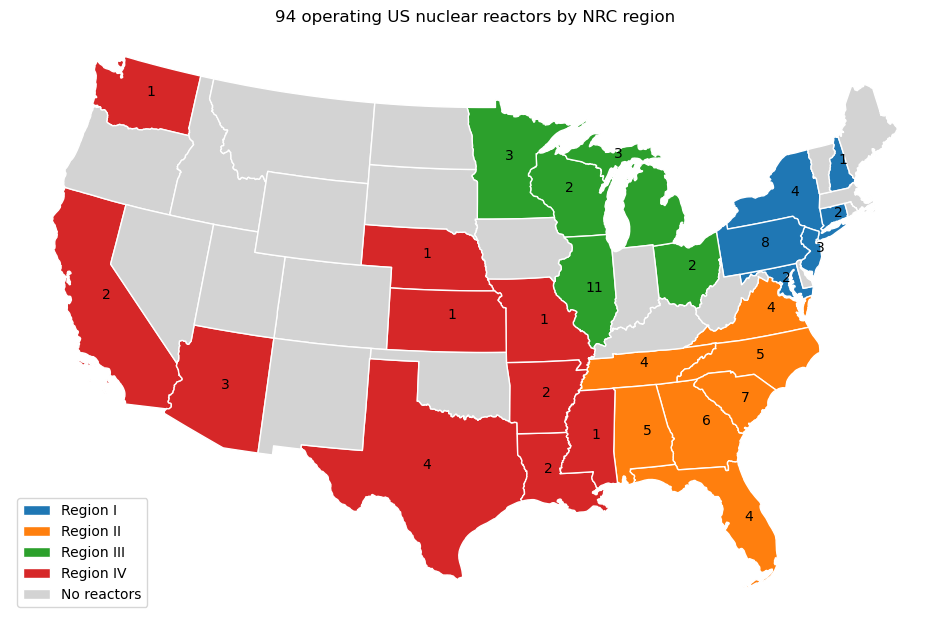

In [200]:
import geopandas as gpd
import matplotlib.pyplot as plt

# The other columns from the data frame will be dropped. Reset_Index will create a DataFrame with the number of reactors column as reactors.
# Without reset_index, the groupby() will return a pandas Series.
counts = df.groupby(["Region", "State"]).size().reset_index(name="reactors")
print(counts)


# This is a table containing the state names and their corresponding geometries
states = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip")

# Not including Alska, Hawai and Peurto Rico
states = states.query("NAME not in ['Alaska', 'Hawaii', 'Puerto Rico']")

# A more ususal way of plotting. Without this the map would appear flat.
states = states.to_crs(epsg=5070)

# We merge the two tables by the States (the corresponding column is called Name in the states table and State in the counts table)
# how = left means whichever rows are not matched they are kept with NaN in the reactors column
states = states.merge(counts, left_on="NAME", right_on="State", how="left")

# Coloring by Region
ax = states.plot(column="Region", legend=True, edgecolor="white", figsize=(12, 8), missing_kwds={"color": "lightgrey", "label": "No reactors"}, legend_kwds={"loc": "lower left"})
                 
# Only writing the number of reactors for the states with nuclear reactors. The rows with NaN in the reactors column are dropped
labeled = states.dropna(subset=["reactors"])
for point, n in zip(labeled.representative_point(), labeled["reactors"]):
    ax.annotate(int(n), (point.x, point.y))
    
ax.set_title(f"{len(df)} operating US nuclear reactors by NRC region")
ax.set_axis_off()

<Axes: xlabel='Region'>

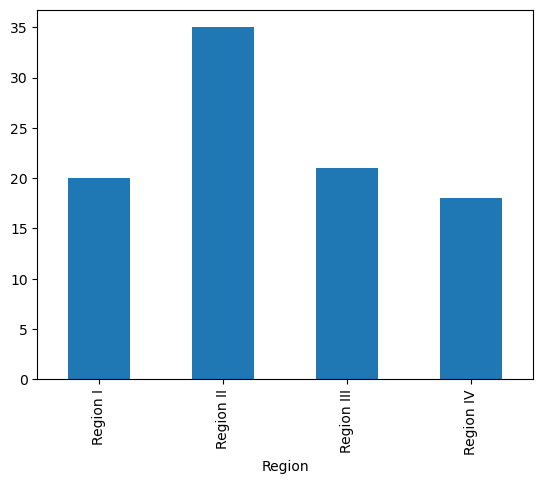

In [196]:
df['Region'].value_counts().sort_index().plot.bar()